## Week 9 — Multi-Fidelity GP (Matérn-5/2 ARD + LinTrunc) + MF-qNEI

This notebook fits a **Multi-Fidelity Gaussian Process (MFGP)** surrogate on all cumulative
Week 9 data (39 samples) and proposes the next warehouse configuration using **Cost-aware MF-qNEI**.

**Why MFGP for Week 9?**
- The MFGP with Matérn-5/2 ARD + `LinearTruncatedFidelityKernel` was the **Prequential Evaluation winner**
  for F4, achieving the best NLP of -1.35 across 45 tested configurations.
- Although all data is single-fidelity, the `LinearTruncatedFidelityKernel` provides beneficial
  regularisation via its structured prior on spatial-fidelity kernel interaction.
- **MF-qNEI** (q=4, 64 MC samples) jointly proposes 4 candidates; the best is selected for submission.

**Week 9 enhancements:** Three-colour visualisation (blue=initial, orange=submissions, green★=proposed) and quantitative performance evaluation (convergence metrics, exploration spread, LOO surrogate error).

In [12]:
import copy
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform

from botorch.models import SingleTaskMultiFidelityGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.constraints import GreaterThan
from gpytorch.likelihoods import GaussianLikelihood

# Suppress convergence warnings from L-BFGS during MLL fitting
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Strategy Recap (Carried from Week 8)

| # | Hyperparameter | Value | Justification |
|---|---------------|-------|---------------|
| 1 | Kernel ν (nu) | 2.5 | Matérn-5/2 — PE winner for F4 |
| 2 | `linear_truncated` | `True` | LinearTruncatedFidelityKernel; PE winner |
| 3 | ARD dimensions | 4 spatial + 1 fidelity | Each dimension gets its own lengthscale |
| 4 | Noise floor (`noise_lb`) | 1e-4 | Prevents noise collapsing to zero |
| 5 | Output standardisation | z-score | Manual `(y - mean) / std` |
| 6 | MLL restarts (`N_RESTARTS`) | 15 | Avoids local optima |
| 7 | Fidelity column | All 1.0 (column index 4) | Synthetic single-fidelity |
| 8 | `data_fidelities` | `[4]` | Column 4 = fidelity dimension |
| 9 | Acquisition | `qLogNoisyExpectedImprovement` | Log-space NEI |
| 10 | Batch size (`q`) | 4 | Joint optimisation; best selected |
| 11 | MC samples | 64 | `SobolQMCNormalSampler` |
| 12 | Acquisition restarts | 20 | Multi-start L-BFGS-B |
| 13 | Raw Sobol samples | 512 | Initialisation points |
| 14 | `fixed_features` | `{4: 1.0}` | Pin fidelity during acquisition |
| 15 | `prune_baseline` | `True` | Removes dominated baseline points |
| 16 | Spatial bounds | `[0, 0.999999]⁴` | Challenge format constraint |

In [13]:
# ── Constants ──
N_INITIAL = 30
N_TOTAL = 39
N_DIMS = 4
N_SUBMISSIONS = N_TOTAL - N_INITIAL       # 9 weekly submissions
STALLING_WINDOW = 3                        # minimum consecutive non-improving submissions
STALLING_REL_THRESHOLD = 0.05             # 5 % relative improvement threshold

N_RESTARTS = 15
NOISE_LB = 1e-4
Q = 4
MC_SAMPLES = 64
ACQ_RESTARTS = 20
RAW_SAMPLES = 512
GRID_RES = 80
DIM = N_DIMS

### Step 1: Load Week 9 Data (30 initial + 9 submissions = 39 samples)

In [14]:
# Load cumulative Week 9 data
X_raw = np.load('../../data/f4/updated_inputs - Week 9.npy')
y_raw = np.load('../../data/f4/updated_outputs - Week 9.npy')

n_samples = len(y_raw)
best_idx = y_raw.argmax()
best_val = y_raw[best_idx]

assert X_raw.shape == (N_TOTAL, N_DIMS), f"Expected ({N_TOTAL}, {N_DIMS}), got {X_raw.shape}"
assert y_raw.shape == (N_TOTAL,), f"Expected ({N_TOTAL},), got {y_raw.shape}"

# Split for visualisation
X_initial = X_raw[:N_INITIAL]
y_initial = y_raw[:N_INITIAL]
X_submissions = X_raw[N_INITIAL:]
y_submissions = y_raw[N_INITIAL:]

print(f"Week 9 Data Summary for F4")
print(f"{'='*40}")
print(f"Number of samples:  {n_samples}")
print(f"  Initial: {len(X_initial)}, Submissions: {len(X_submissions)}")
print(f"Input dimensions:   {X_raw.shape[1]}")
print(f"Input range:        [{X_raw.min():.6f}, {X_raw.max():.6f}]")
for dim in range(DIM):
    print(f"  Dim {dim+1}:            [{X_raw[:, dim].min():.6f}, {X_raw[:, dim].max():.6f}]")
print(f"Output range:       [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Output mean:        {y_raw.mean():.6f}")
print(f"Output std:         {y_raw.std():.6f}")
print(f"Best observed value: {best_val:.6f} (sample #{best_idx + 1})")
print(f"  ({'initial' if best_idx < N_INITIAL else f'submission wk{best_idx - N_INITIAL + 1}'})")

# Validate inputs in [0, 1]
assert np.all((X_raw >= 0.0) & (X_raw <= 1.0)), "Inputs out of [0, 1] range"
print(f"\n✓ All inputs are within [0.0, 1.0]")

Week 9 Data Summary for F4
Number of samples:  39
  Initial: 30, Submissions: 9
Input dimensions:   4
Input range:        [0.006250, 0.999483]
  Dim 1:            [0.037825, 0.985622]
  Dim 2:            [0.006250, 0.919592]
  Dim 3:            [0.012308, 0.939178]
  Dim 4:            [0.081517, 0.999483]
Output range:       [-32.625660, 0.532175]
Output mean:        -13.595449
Output std:         9.185044
Best observed value: 0.532175 (sample #33)
  (submission wk3)

✓ All inputs are within [0.0, 1.0]


### Step 2: Train MFGP with 15 Random Restarts (39 samples)

Z-score standardise outputs, append fidelity column, then train with multi-restart MLL.

In [15]:
# Z-score standardise outputs
y_mean = float(y_raw.mean())
y_std_val = float(y_raw.std())
y_standardised = (y_raw - y_mean) / y_std_val

# Convert to torch tensors
X_train = torch.tensor(X_raw, dtype=torch.float64)
Y_train = torch.tensor(y_standardised, dtype=torch.float64).unsqueeze(-1)

# Append fidelity column (all 1.0) → 5D augmented input
fidelity_col = torch.ones(X_train.shape[0], 1, dtype=torch.float64)
X_mf = torch.cat([X_train, fidelity_col], dim=-1)
print(f"X_mf shape: {X_mf.shape}  (4 spatial + 1 fidelity)")
print(f"Y_train shape: {Y_train.shape}  (z-scored)")
print(f"y_mean={y_mean:.6f}, y_std={y_std_val:.6f}")

# Multi-restart MLL training
best_loss = float('inf')
best_model = None
best_seed = -1

print(f"\nTraining MFGP with {N_RESTARTS} random restarts...")
print(f"{'─'*55}")

for seed in range(N_RESTARTS):
    torch.manual_seed(seed)
    try:
        likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))
        model = SingleTaskMultiFidelityGP(
            X_mf, Y_train,
            likelihood=likelihood,
            data_fidelities=[4],
            linear_truncated=True,
            nu=2.5,
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)

        model.train()
        with torch.no_grad():
            output = model(X_mf)
            loss = -mll(output, Y_train.squeeze(-1)).item()

        status = f"neg_MLL = {loss:.4f}"
        if loss < best_loss:
            best_loss = loss
            best_model = copy.deepcopy(model)
            best_seed = seed
            status += " ★ new best"
    except Exception as e:
        status = f"FAILED ({type(e).__name__})"

    print(f"  Restart {seed+1:2d}/{N_RESTARTS}: {status}")

assert best_model is not None, "All restarts failed!"
best_model.eval()

# Extract fitted hyperparameters
fid_kernel = best_model.covar_module.base_kernel.kernels[0]
ls = fid_kernel.covar_module_unbiased.lengthscale.detach().squeeze()
outputscale = best_model.covar_module.outputscale.item()
noise = best_model.likelihood.noise.item()
power = fid_kernel.power.item()

print(f"\n{'='*55}")
print(f"Best Model (restart {best_seed+1}, neg_MLL = {best_loss:.4f})")
print(f"{'─'*55}")
for i in range(DIM):
    print(f"  ℓ{i+1} = {ls[i].item():.6f}")
print(f"  σ²_f (outputscale) = {outputscale:.6f}")
print(f"  σ²_n (noise)       = {noise:.6f}  {'✓ ≥ 1e-4' if noise >= NOISE_LB else '⚠️ below floor!'}")
print(f"  Fidelity power     = {power:.6f}")

X_mf shape: torch.Size([39, 5])  (4 spatial + 1 fidelity)
Y_train shape: torch.Size([39, 1])  (z-scored)
y_mean=-13.595449, y_std=9.185044

Training MFGP with 15 random restarts...
───────────────────────────────────────────────────────
  Restart  1/15: neg_MLL = 0.0917 ★ new best
  Restart  2/15: neg_MLL = 0.0917
  Restart  3/15: neg_MLL = 0.0917
  Restart  4/15: neg_MLL = 0.0917
  Restart  5/15: neg_MLL = 0.0917
  Restart  6/15: neg_MLL = 0.0917
  Restart  7/15: neg_MLL = 0.0917
  Restart  8/15: neg_MLL = 0.0917
  Restart  9/15: neg_MLL = 0.0917
  Restart 10/15: neg_MLL = 0.0917
  Restart 11/15: neg_MLL = 0.0917
  Restart 12/15: neg_MLL = 0.0917
  Restart 13/15: neg_MLL = 0.0917
  Restart 14/15: neg_MLL = 0.0917
  Restart 15/15: neg_MLL = 0.0917

Best Model (restart 1, neg_MLL = 0.0917)
───────────────────────────────────────────────────────
  ℓ1 = 0.810988
  ℓ2 = 0.809920
  ℓ3 = 0.798097
  ℓ4 = 0.766365
  σ²_f (outputscale) = 0.862047
  σ²_n (noise)       = 0.000100  ✓ ≥ 1e-4
  Fide

### Step 3: MF-qNEI Acquisition — Propose q=4 Candidates

Joint optimisation of 4 candidates with fidelity pinned at 1.0. Best candidate selected by highest de-standardised posterior mean.

In [16]:
# Sampler: 64 MC samples
sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))

# Create acquisition function
nei = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_mf,
    sampler=sampler,
    prune_baseline=True,
)

# Bounds: 4 spatial dims [0, 0.999999] + fidelity [1.0, 1.0]
BOUNDS = torch.tensor(
    [[0.0, 0.0, 0.0, 0.0, 1.0],
     [0.999999, 0.999999, 0.999999, 0.999999, 1.0]],
    dtype=torch.float64,
)

# Optimise acquisition (q=4, fidelity pinned at 1.0)
print(f"Optimising MF-qNEI (q={Q}, {MC_SAMPLES} MC samples, {ACQ_RESTARTS} restarts)...")
candidates, acq_value = optimize_acqf(
    acq_function=nei,
    bounds=BOUNDS,
    q=Q,
    num_restarts=ACQ_RESTARTS,
    raw_samples=RAW_SAMPLES,
    fixed_features={4: 1.0},
)

# Extract spatial coordinates (drop fidelity column)
next_points = candidates[:, :DIM].detach().cpu().numpy()

print(f"\n{'='*60}")
print(f"MF-qNEI Results — {Q} Candidates")
print(f"{'─'*60}")
for i in range(Q):
    coords = ", ".join([f"{next_points[i, d]:.6f}" for d in range(DIM)])
    print(f"  Candidate {i+1}: [{coords}]")
print(f"{'─'*60}")
print(f"Joint acquisition value: {acq_value.item():.6f}")

# Select best candidate by posterior mean
with torch.no_grad():
    candidate_tensor = candidates.detach()
    posterior = best_model.posterior(candidate_tensor)
    posterior_means = posterior.mean.squeeze()
    posterior_means_orig = posterior_means * y_std_val + y_mean

best_candidate_idx = posterior_means_orig.argmax().item()
best_point = next_points[best_candidate_idx]

print(f"\nBest candidate: #{best_candidate_idx + 1} (posterior mean = {posterior_means_orig[best_candidate_idx].item():.6f})")
print(f"  Selected point: [{', '.join([f'{v:.6f}' for v in best_point])}]")

Optimising MF-qNEI (q=4, 64 MC samples, 20 restarts)...

MF-qNEI Results — 4 Candidates
────────────────────────────────────────────────────────────
  Candidate 1: [0.396298, 0.444560, 0.401205, 0.393235]
  Candidate 2: [0.426399, 0.422919, 0.438869, 0.420198]
  Candidate 3: [0.413673, 0.546200, 0.552140, 0.485228]
  Candidate 4: [0.416091, 0.450761, 0.453604, 0.418647]
────────────────────────────────────────────────────────────
Joint acquisition value: -5.456552

Best candidate: #2 (posterior mean = 0.442610)
  Selected point: [0.426399, 0.422919, 0.438869, 0.420198]


### Step 4: Three-Colour Surrogate Visualisation — 2D Slices

Project onto the two most important dimensions (shortest ARD lengthscales), fixing others at the proposed point.

ARD lengthscales: ['0.8110', '0.8099', '0.7981', '0.7664']
Top-2 dims (shortest ℓ): ['Dim 4', 'Dim 3']
Fixed dims: ['Dim 2', 'Dim 1'] at proposed point values


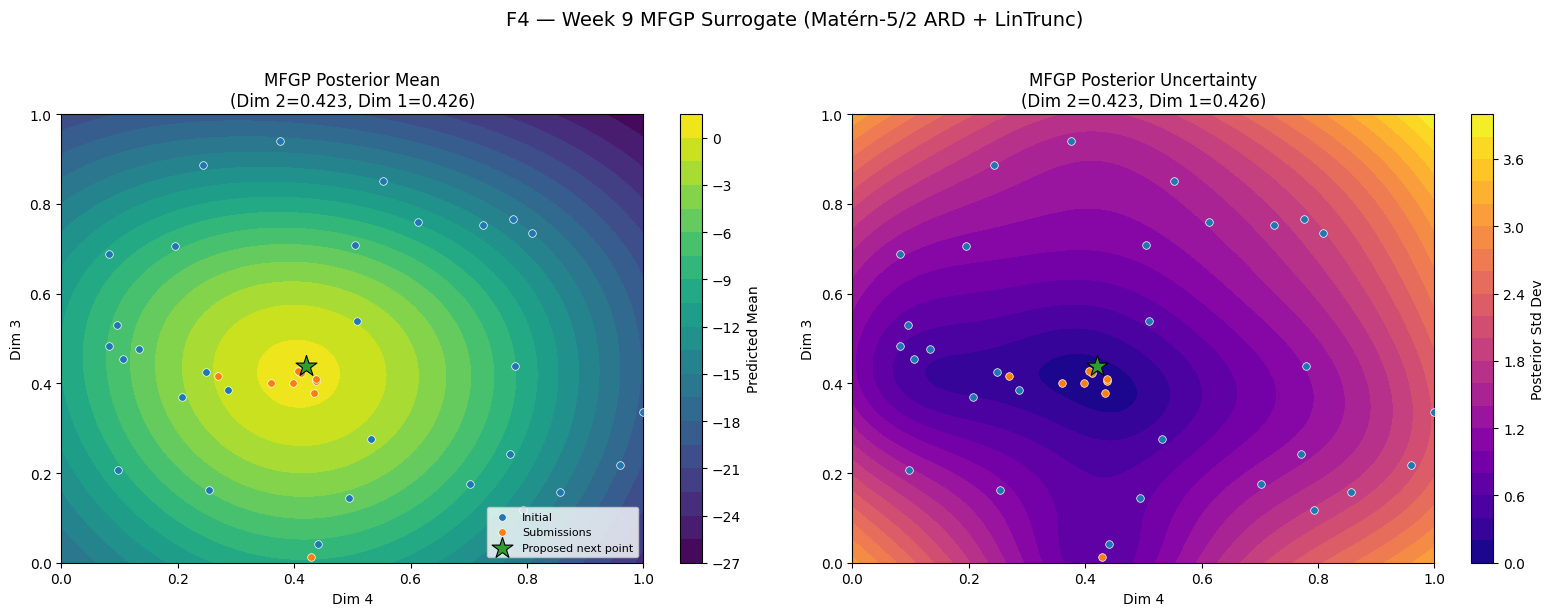

In [17]:
# Identify top-2 dims by shortest ARD lengthscales
lengthscales = ls.numpy()
dim_order = np.argsort(lengthscales)
top2 = dim_order[:2].tolist()
fix2 = dim_order[2:].tolist()
dim_names = ['Dim 1', 'Dim 2', 'Dim 3', 'Dim 4']

print(f"ARD lengthscales: {['%.4f' % l for l in lengthscales]}")
print(f"Top-2 dims (shortest ℓ): {[dim_names[d] for d in top2]}")
print(f"Fixed dims: {[dim_names[d] for d in fix2]} at proposed point values")

# Build grid over top-2 dims
g1 = np.linspace(0, 1, GRID_RES)
g2 = np.linspace(0, 1, GRID_RES)
mesh1, mesh2 = np.meshgrid(g1, g2)

grid_points = np.zeros((GRID_RES * GRID_RES, DIM))
grid_points[:, top2[0]] = mesh1.ravel()
grid_points[:, top2[1]] = mesh2.ravel()
for fd in fix2:
    grid_points[:, fd] = best_point[fd]

# Append fidelity column for MFGP
fid_col = np.ones((GRID_RES * GRID_RES, 1))
grid_5d = np.hstack([grid_points, fid_col])
grid_tensor = torch.tensor(grid_5d, dtype=torch.float64)

with torch.no_grad():
    posterior = best_model.posterior(grid_tensor)
    mean_std = posterior.mean.squeeze().numpy()
    std_std = posterior.variance.squeeze().sqrt().numpy()

mean_orig = mean_std * y_std_val + y_mean
std_orig = std_std * y_std_val

mean_grid = mean_orig.reshape(GRID_RES, GRID_RES)
std_grid = std_orig.reshape(GRID_RES, GRID_RES)

# 2-panel: mean + std — three-colour scheme
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cf1 = ax1.contourf(mesh1, mesh2, mean_grid, levels=20, cmap='viridis')
plt.colorbar(cf1, ax=ax1, label='Predicted Mean')
ax1.scatter(X_initial[:, top2[0]], X_initial[:, top2[1]], c='tab:blue', s=30,
            edgecolors='white', linewidths=0.5, zorder=5, label='Initial')
ax1.scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]], c='tab:orange', s=30,
            edgecolors='white', linewidths=0.5, zorder=5, label='Submissions')
ax1.scatter(best_point[top2[0]], best_point[top2[1]], marker='*', c='tab:green',
            s=250, edgecolors='black', linewidths=0.8, zorder=6, label='Proposed next point')
ax1.set_xlabel(dim_names[top2[0]])
ax1.set_ylabel(dim_names[top2[1]])
ax1.set_title(f'MFGP Posterior Mean\n({dim_names[fix2[0]]}={best_point[fix2[0]]:.3f}, '
              f'{dim_names[fix2[1]]}={best_point[fix2[1]]:.3f})')
ax1.legend(loc='lower right', fontsize=8)

cf2 = ax2.contourf(mesh1, mesh2, std_grid, levels=20, cmap='plasma')
plt.colorbar(cf2, ax=ax2, label='Posterior Std Dev')
ax2.scatter(X_initial[:, top2[0]], X_initial[:, top2[1]], c='tab:blue', s=30,
            edgecolors='white', linewidths=0.5, zorder=5)
ax2.scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]], c='tab:orange', s=30,
            edgecolors='white', linewidths=0.5, zorder=5)
ax2.scatter(best_point[top2[0]], best_point[top2[1]], marker='*', c='tab:green',
            s=250, edgecolors='black', linewidths=0.8, zorder=6)
ax2.set_xlabel(dim_names[top2[0]])
ax2.set_ylabel(dim_names[top2[1]])
ax2.set_title(f'MFGP Posterior Uncertainty\n({dim_names[fix2[0]]}={best_point[fix2[0]]:.3f}, '
              f'{dim_names[fix2[1]]}={best_point[fix2[1]]:.3f})')

plt.suptitle('F4 — Week 9 MFGP Surrogate (Matérn-5/2 ARD + LinTrunc)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Step 5: Three-Colour Convergence Plot

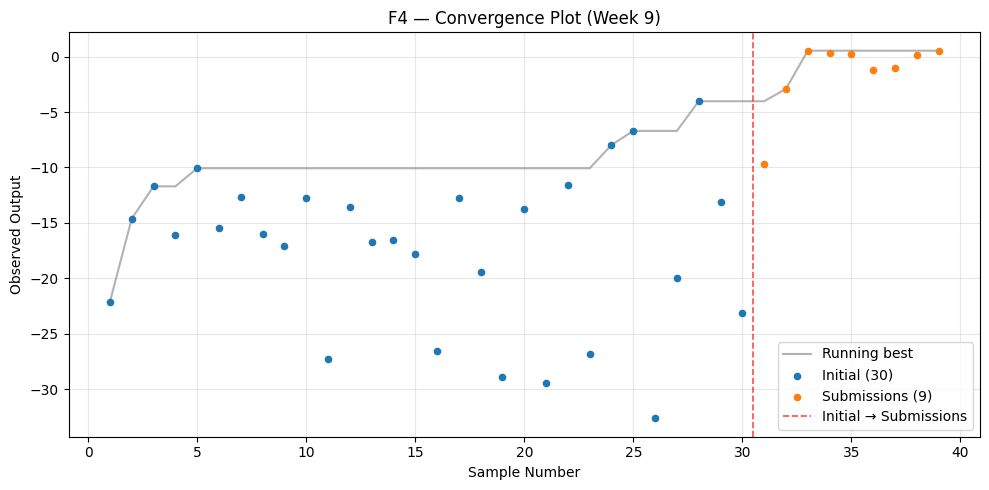

Best after initial 30 samples: -4.025542
Best after Week 9 (39 samples): 0.532175
Improvement from weekly submissions: 4.557718


In [18]:
# Convergence plot — three-colour scheme
running_best = np.maximum.accumulate(y_raw)
sample_numbers = np.arange(1, len(y_raw) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sample_numbers, running_best, color='grey', linewidth=1.5, alpha=0.6, label='Running best')

# Blue: initial, Orange: submissions
ax.scatter(sample_numbers[:N_INITIAL], y_raw[:N_INITIAL], c='tab:blue', s=20, zorder=3, label=f'Initial ({N_INITIAL})')
ax.scatter(sample_numbers[N_INITIAL:], y_raw[N_INITIAL:], c='tab:orange', s=20, zorder=3, label=f'Submissions ({N_SUBMISSIONS})')

ax.axvline(x=N_INITIAL + 0.5, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Initial → Submissions')

ax.set_xlabel('Sample Number')
ax.set_ylabel('Observed Output')
ax.set_title('F4 — Convergence Plot (Week 9)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best after initial {N_INITIAL} samples: {running_best[N_INITIAL-1]:.6f}")
print(f"Best after Week 9 ({n_samples} samples): {running_best[-1]:.6f}")
improvement = running_best[-1] - running_best[N_INITIAL-1]
print(f"Improvement from weekly submissions: {improvement:.6f}")

### Step 6: Week 9 Submission

Select the best-of-4 candidate, clamp to [0, 0.999999], and format as 4-component dash-separated string.

In [19]:
# Clamp and format
clamped = np.clip(best_point, 0.0, 0.999999)
submission = "-".join([f"{x:.6f}" for x in clamped])

# Validate
parts = submission.split("-")
valid = (len(parts) == DIM and
         all(p[0] == '0' for p in parts) and
         all(0.0 <= float(p) <= 1.0 for p in parts))

# Duplicate check
distances = np.linalg.norm(X_raw - clamped, axis=1)
min_dist = distances.min()
is_duplicate = min_dist < 1e-6

print(f"F4 WEEK 9 SUBMISSION")
print(f"{'='*55}")
print(f"Surrogate:    MFGP (Matérn-5/2 ARD + LinTrunc)")
print(f"Acquisition:  MF-qNEI (q={Q}, {MC_SAMPLES} MC samples)")
print(f"{'─'*55}")
print(f"Fitted hyperparameters:")
for i in range(DIM):
    print(f"  ℓ{i+1} = {ls[i].item():.6f}")
print(f"  σ²_f = {outputscale:.6f}")
print(f"  σ²_n = {noise:.6f}")
print(f"{'─'*55}")
print(f"Proposed point: [{', '.join([f'{v:.6f}' for v in best_point])}]")
if is_duplicate:
    print(f"⚠  Near-duplicate at distance {min_dist:.8f}")
else:
    print(f"✓ No duplicate (min dist: {min_dist:.6f})")
print(f"{'─'*55}")
print(f"\n>>> WEEK 9 SUBMISSION QUERY:")
print(submission)
print(f"\nFormat valid: {'✓ YES' if valid else '✗ NO'}")

F4 WEEK 9 SUBMISSION
Surrogate:    MFGP (Matérn-5/2 ARD + LinTrunc)
Acquisition:  MF-qNEI (q=4, 64 MC samples)
───────────────────────────────────────────────────────
Fitted hyperparameters:
  ℓ1 = 0.810988
  ℓ2 = 0.809920
  ℓ3 = 0.798097
  ℓ4 = 0.766365
  σ²_f = 0.862047
  σ²_n = 0.000100
───────────────────────────────────────────────────────
Proposed point: [0.426399, 0.422919, 0.438869, 0.420198]
✓ No duplicate (min dist: 0.026737)
───────────────────────────────────────────────────────

>>> WEEK 9 SUBMISSION QUERY:
0.426399-0.422919-0.438869-0.420198

Format valid: ✓ YES


---
## Performance Evaluation

### Cell 10 — Convergence Metrics & Stalling Detection

In [20]:
# ── Cell 10: Convergence Metrics & Stalling Detection ──
best_trajectory = np.maximum.accumulate(y_submissions)
improvements = np.diff(best_trajectory, prepend=best_trajectory[0])

# Stalling: count consecutive non-improving submissions from the tail
consecutive_no_improvement = 0
for val in reversed(improvements):
    if val <= 0:
        consecutive_no_improvement += 1
    else:
        break

# Relative improvement
best_initial = y_initial.max()
best_overall = y_raw.max()
if best_initial != 0:
    relative_improvement = (best_overall - best_initial) / abs(best_initial)
else:
    relative_improvement = float('inf') if best_overall > best_initial else 0.0

stalling = (consecutive_no_improvement >= STALLING_WINDOW) or (relative_improvement < STALLING_REL_THRESHOLD)

print("=" * 60)
print("CONVERGENCE METRICS")
print("=" * 60)
print(f"  Best initial value:          {best_initial:.6f}")
print(f"  Best overall value:          {best_overall:.6f}")
print(f"  Relative improvement:        {relative_improvement:.4f} ({relative_improvement*100:.1f}%)")
print(f"  Consecutive non-improving:   {consecutive_no_improvement} (threshold: {STALLING_WINDOW})")
print(f"  STALLING:                    {'YES ⚠' if stalling else 'NO ✓'}")
print()

# Per-submission trajectory
print("Per-submission trajectory (submissions only):")
for i, (val, best_so_far) in enumerate(zip(y_submissions, best_trajectory)):
    improved = "★" if (i == 0 and val > best_initial) or (i > 0 and best_so_far > best_trajectory[i-1]) else " "
    print(f"  Submission {i+1}: y={val:.6f}  best_so_far={best_so_far:.6f}  {improved}")

CONVERGENCE METRICS
  Best initial value:          -4.025542
  Best overall value:          0.532175
  Relative improvement:        1.1322 (113.2%)
  Consecutive non-improving:   6 (threshold: 3)
  STALLING:                    YES ⚠

Per-submission trajectory (submissions only):
  Submission 1: y=-9.720482  best_so_far=-9.720482   
  Submission 2: y=-2.912760  best_so_far=-2.912760  ★
  Submission 3: y=0.532175  best_so_far=0.532175  ★
  Submission 4: y=0.338389  best_so_far=0.532175   
  Submission 5: y=0.244750  best_so_far=0.532175   
  Submission 6: y=-1.189486  best_so_far=0.532175   
  Submission 7: y=-1.037067  best_so_far=0.532175   
  Submission 8: y=0.155771  best_so_far=0.532175   
  Submission 9: y=0.523825  best_so_far=0.532175   


### Cell 11 — Exploration Spread (Pairwise Distance Analysis)

EXPLORATION SPREAD
  Submission pairwise distances (n=36):
    Mean:  0.1938  (uniform reference: ~0.73)
    Min:   0.0191
    Max:   0.4782
    Ratio: 0.27x (>1 = spread beyond uniform)
  Nearest-neighbour to prior data:
    Mean:  0.1179
    Min:   0.0191
    Max:   0.4637


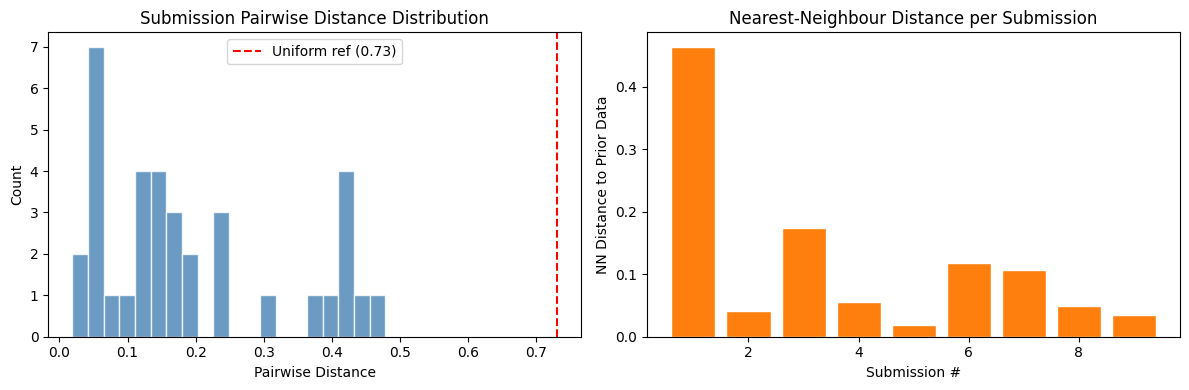

In [21]:
# ── Cell 11: Exploration Spread ──
EXPECTED_UNIFORM = 0.73  # 4D reference (unit hypercube)

# Pairwise distances — submissions only
dists_sub = pdist(X_submissions)
mean_dist = np.mean(dists_sub)
min_dist_spread = np.min(dists_sub)
max_dist = np.max(dists_sub)

# Nearest-neighbour distances — each submission to prior data
nn_dists = []
for i in range(len(X_submissions)):
    d = np.linalg.norm(X_raw[:N_INITIAL + i] - X_submissions[i], axis=1)
    nn_dists.append(d.min())
nn_dists = np.array(nn_dists)

print("=" * 60)
print("EXPLORATION SPREAD")
print("=" * 60)
print(f"  Submission pairwise distances (n={len(dists_sub)}):")
print(f"    Mean:  {mean_dist:.4f}  (uniform reference: ~{EXPECTED_UNIFORM})")
print(f"    Min:   {min_dist_spread:.4f}")
print(f"    Max:   {max_dist:.4f}")
print(f"    Ratio: {mean_dist/EXPECTED_UNIFORM:.2f}x (>1 = spread beyond uniform)")
print(f"  Nearest-neighbour to prior data:")
print(f"    Mean:  {nn_dists.mean():.4f}")
print(f"    Min:   {nn_dists.min():.4f}")
print(f"    Max:   {nn_dists.max():.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dists_sub, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(EXPECTED_UNIFORM, color="red", linestyle="--", label=f"Uniform ref ({EXPECTED_UNIFORM})")
axes[0].set_xlabel("Pairwise Distance")
axes[0].set_ylabel("Count")
axes[0].set_title("Submission Pairwise Distance Distribution")
axes[0].legend()

axes[1].bar(range(1, len(nn_dists)+1), nn_dists, color="tab:orange", edgecolor="white")
axes[1].set_xlabel("Submission #")
axes[1].set_ylabel("NN Distance to Prior Data")
axes[1].set_title("Nearest-Neighbour Distance per Submission")
plt.tight_layout()
plt.show()

### Cell 12 — Leave-One-Out Surrogate Error (MFGP Matérn-2.5 + LinTrunc)

In [22]:
# ── Cell 12: Leave-One-Out Surrogate Error (MFGP) ──
# Retrain SingleTaskMultiFidelityGP on submissions only (9 folds)
# Recompute z-score per fold, append fidelity column, reduce restarts to 5

loo_errors = []
n_sub = len(X_submissions)

print(f"LOO Cross-Validation ({n_sub} folds, submissions only)")
print(f"{'Fold':>5} {'True':>12} {'Pred':>12} {'AbsErr':>10} {'Status':>8}")
print("-" * 55)

for i in range(n_sub):
    # Leave one out
    mask = np.ones(n_sub, dtype=bool)
    mask[i] = False
    X_fold = X_submissions[mask]
    y_fold_raw = y_submissions[mask]
    
    # Recompute z-score on fold
    fold_mean = float(y_fold_raw.mean())
    fold_std = float(y_fold_raw.std())
    fold_std_safe = fold_std if fold_std > 1e-8 else 1.0
    y_fold_std = (y_fold_raw - fold_mean) / fold_std_safe
    
    X_t = torch.tensor(X_fold, dtype=torch.float64)
    Y_t = torch.tensor(y_fold_std, dtype=torch.float64).unsqueeze(-1)
    
    # Append fidelity column
    fid = torch.ones(X_t.shape[0], 1, dtype=torch.float64)
    X_mf_fold = torch.cat([X_t, fid], dim=-1)
    
    # Retrain with 5 restarts
    best_fold_loss = float('inf')
    best_fold_model = None
    
    for seed in range(5):
        torch.manual_seed(seed + 200)
        try:
            lik = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))
            m = SingleTaskMultiFidelityGP(
                X_mf_fold, Y_t,
                likelihood=lik,
                data_fidelities=[4],
                linear_truncated=True,
                nu=2.5,
            )
            mll_fold = ExactMarginalLogLikelihood(m.likelihood, m)
            fit_gpytorch_mll(mll_fold)
            m.train()
            with torch.no_grad():
                out = m(X_mf_fold)
                loss = -mll_fold(out, Y_t.squeeze(-1)).item()
            if loss < best_fold_loss:
                best_fold_loss = loss
                best_fold_model = copy.deepcopy(m)
        except Exception:
            continue
    
    if best_fold_model is None:
        print(f"{i+1:>5} {'FAILED':>12}")
        continue
    
    # Predict held-out point
    x_test = torch.tensor(X_submissions[i:i+1], dtype=torch.float64)
    x_test_mf = torch.cat([x_test, torch.ones(1, 1, dtype=torch.float64)], dim=-1)
    best_fold_model.eval()
    with torch.no_grad():
        pred_std = best_fold_model.posterior(x_test_mf).mean.item()
    
    # De-standardise
    pred_orig = pred_std * fold_std_safe + fold_mean
    true_orig = y_submissions[i]
    err = abs(pred_orig - true_orig)
    loo_errors.append(err)
    
    status = "✓" if err < abs(true_orig) * 0.5 else "⚠"
    print(f"{i+1:>5} {true_orig:>12.4f} {pred_orig:>12.4f} {err:>10.4f} {status:>8}")

loo_errors = np.array(loo_errors)
print(f"\n{'='*55}")
print(f"LOO Summary:")
print(f"  MAE:     {loo_errors.mean():.4f}")
print(f"  Median:  {np.median(loo_errors):.4f}")
print(f"  Max:     {loo_errors.max():.4f}")
print(f"  StdDev:  {loo_errors.std():.4f}")
print(f"  Output range: [{y_submissions.min():.4f}, {y_submissions.max():.4f}]")
print(f"  Relative MAE: {loo_errors.mean() / (y_submissions.max() - y_submissions.min() + 1e-10):.4f}")

LOO Cross-Validation (9 folds, submissions only)
 Fold         True         Pred     AbsErr   Status
-------------------------------------------------------
    1      -9.7205      -1.6328     8.0877        ⚠
    2      -2.9128      -1.5386     1.3741        ✓
    3       0.5322       0.1372     0.3949        ⚠
    4       0.3384       0.2862     0.0522        ✓
    5       0.2448       0.3263     0.0815        ✓
    6      -1.1895      -0.3958     0.7936        ⚠
    7      -1.0371      -0.9266     0.1104        ✓
    8       0.1558       0.4213     0.2655        ⚠
    9       0.5238       0.6901     0.1663        ✓

LOO Summary:
  MAE:     1.2585
  Median:  0.2655
  Max:     8.0877
  StdDev:  2.4484
  Output range: [-9.7205, 0.5322]
  Relative MAE: 0.1227


### Cell 13 — Interpretation & Strategy Recommendations

**F4 Strategy Assessment (Week 9):**

- **Surrogate**: SingleTaskMultiFidelityGP with LinearTruncatedFidelityKernel (synthetic single-fidelity). The multi-fidelity structure acts as a regulariser despite all data being at fidelity=1.0.
- **Acquisition**: MF-qNEI q=4, then best-by-posterior-mean selection. 64 MC samples is relatively low.

**Recommendations for Week 10:**
1. **Switch to standard SingleTaskGP** — the MFGP regularisation benefit may diminish with 39+ samples; a simpler model could fit faster and more accurately
2. **Reduce q from 4 to 1** — with enough data, single-point NEI with more restarts may be more reliable than batch selection
3. **Add interior penalty (S=0.5, F=0.01)** — if boundary-hugging is observed, the 4x(1−x) additive log-space penalty from F5 can help